# Ejemplo End-to-End: Pandas con Titanic

En este notebook haremos un flujo más completo y realista de análisis con pandas usando el dataset del Titanic.

La idea no es solo mirar algunas columnas, sino recorrer un mini proceso end-to-end:

1. **Carga de datos**
2. **Exploración inicial**
3. **Calidad de datos**
4. **Limpieza**
5. **Feature engineering**
6. **Análisis con `groupby`, `pivot_table` y ranking**
7. **Segmentación de pasajeros**
8. **Visualización básica**
9. **Tabla ejecutiva final**

Este ejemplo mezcla varias operaciones de pandas en un caso más cercano a un análisis real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print('Shape inicial:', df.shape)
display(df.head())

Shape inicial: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


| Variable | Description                       | Details                                        |
| -------- | --------------------------------- | ---------------------------------------------- |
| survival | Survival                          | 0 = No; 1 = Yes                                |
| pclass   | Passenger Class                   | 1 = 1st; 2 = 2nd; 3 = 3rd                      |
| name     | First and Last Name               |                                                |
| sex      | Sex                               |                                                |
| age      | Age                               |                                                |
| sibsp    | Number of Siblings/Spouses Aboard |                                                |
| parch    | Number of Parents/Children Aboard |                                                |
| ticket   | Ticket Number                     |                                                |
| fare     | Passenger Fare                    |                                                |
| cabin    | Cabin                             |                                                |
| embarked | Port of Embarkation               | C = Cherbourg; Q = Queenstown; S = Southampton |

## 1. Exploración inicial

Primero entendemos rápidamente qué trae la base.

In [2]:
print('Columnas:')
print(df.columns.tolist())

print('\nTipos de dato:')
display(df.dtypes.to_frame('dtype'))

print('\nResumen numérico:')
display(df.describe())

print('\nResumen categórico:')
display(df.describe(include='object'))

Columnas:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Tipos de dato:


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64



Resumen numérico:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Resumen categórico:


/var/folders/_6/ql_r_jq502lgnb5k_jw8b46r0000gn/T/ipykernel_58294/2262289994.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 2. Calidad de datos

Antes de transformar, revisamos nulos, duplicados y algunas validaciones básicas.

In [3]:
quality = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'n_unicos': df.nunique(dropna=False)
}).sort_values('pct_nulos', ascending=False)

display(quality)

print('Filas duplicadas:', df.duplicated().sum())
print('Fare negativos:', (df['Fare'] < 0).sum())
print('Age negativos:', (df['Age'] < 0).sum())

,nulos,pct_nulos,n_unicos
Cabin,687,77.10,148
Age,177,19.87,89
Embarked,2,0.22,4
PassengerId,0,0.00,891
Survived,0,0.00,2
Pclass,0,0.00,3
Name,0,0.00,891
Sex,0,0.00,2
SibSp,0,0.00,7
Parch,0,0.00,7


Filas duplicadas: 0
Fare negativos: 0
Age negativos: 0


## 3. Limpieza de datos

Vamos a hacer una limpieza un poco más pensada:

- `Cabin` tiene demasiados nulos, así que no la usaremos completa.
- `Age` la imputamos con la mediana por sexo y clase.
- `Embarked` la completamos con la moda.
- Creamos una copia limpia para no perder el original.

In [4]:
df_clean = df.copy()

# Extraemos solo la letra de la cabina cuando exista
df_clean['CabinDeck'] = df_clean['Cabin'].str[0]

# Imputación de Age usando mediana por Sex y Pclass
df_clean['Age'] = df_clean.groupby(['Sex', 'Pclass'])['Age'].transform(lambda s: s.fillna(s.median()))

# Si aún quedara algún nulo, usamos la mediana global
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Embarked con la moda
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Columnas menos útiles para este análisis
df_clean = df_clean.drop(columns=['Cabin', 'Ticket'])

print('Shape después de limpieza:', df_clean.shape)
print('\nNulos después de limpieza:')
display(df_clean.isna().sum().to_frame('nulos'))

Shape después de limpieza: (891, 11)

Nulos después de limpieza:


,nulos
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


## 4. Feature engineering

Ahora creamos variables más analíticas.

In [12]:
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean[['SibSp','Parch', 'FamilySize']]

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,1,2,4
889,0,0,1


In [13]:
df_clean['IsAlone'] = np.where(df_clean['FamilySize'] == 1, 1, 0)


In [14]:
df_clean['FarePerPerson'] = df_clean['Fare'] / df_clean['FamilySize']


In [15]:
df_clean['AgeBand'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Niño', 'Adolescente', 'Adulto joven', 'Adulto', 'Mayor'],
    include_lowest=True
)

In [16]:
df_clean['FareBand'] = pd.qcut(
    df_clean['Fare'],
    q=4,
    labels=['Bajo', 'Medio-bajo', 'Medio-alto', 'Alto'],
    duplicates='drop'
)

In [17]:
df_clean['Title'] = df_clean['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()


In [18]:
df_clean['Title'] = df_clean['Title'].replace({
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare', 'Don': 'Rare',
    'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare', 'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
})


In [19]:

display(df_clean.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,CabinDeck,FamilySize,IsAlone,FarePerPerson,AgeBand,FareBand,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,NaN,2,0,3.62500,Adulto joven,Bajo,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,C,2,0,35.64165,Adulto,Alto,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,NaN,1,1,7.92500,Adulto joven,Medio-bajo,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,C,2,0,26.55000,Adulto joven,Alto,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,NaN,1,1,8.05000,Adulto joven,Medio-bajo,Mr


## 5. Análisis descriptivo más útil

Aquí ya podemos responder preguntas más interesantes.

In [20]:
print('Tasa global de supervivencia:')
print(round(df_clean['Survived'].mean(), 4))

survival_summary = df_clean.groupby(['Sex', 'Pclass']).agg(
    pasajeros=('PassengerId', 'count'),
    tasa_supervivencia=('Survived', 'mean'),
    edad_promedio=('Age', 'mean'),
    tarifa_promedio=('Fare', 'mean')
).reset_index()

survival_summary['tasa_supervivencia'] = survival_summary['tasa_supervivencia'].round(3)
survival_summary['edad_promedio'] = survival_summary['edad_promedio'].round(1)
survival_summary['tarifa_promedio'] = survival_summary['tarifa_promedio'].round(2)

display(survival_summary.sort_values('tasa_supervivencia', ascending=False))

Tasa global de supervivencia:
0.3838


,Sex,Pclass,pasajeros,tasa_supervivencia,edad_promedio,tarifa_promedio
0,female,1,94,0.968,34.6,106.13
1,female,2,76,0.921,28.7,21.97
2,female,3,144,0.500,21.7,16.12
3,male,1,122,0.369,41.1,67.23
4,male,2,108,0.157,30.7,19.74
5,male,3,347,0.135,26.1,12.66


## 6. `pivot_table` para resumir mejor

Las tablas dinámicas ayudan mucho para presentar resultados.

In [21]:
pivot_survival = pd.pivot_table(
    df_clean,
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
).round(3)

display(pivot_survival)

Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


In [22]:
pivot_fare = pd.pivot_table(
    df_clean,
    values='Fare',
    index='Embarked',
    columns='Pclass',
    aggfunc=['mean', 'median']
).round(2)

display(pivot_fare)

mean               median             
Pclass         1      2      3      1      2     3
Embarked                                          
C         104.72  25.36  11.21  78.27  24.00  7.90
Q          90.00  12.35  11.18  90.00  12.35  7.75
S          70.51  20.33  14.64  52.55  13.50  8.05

## 7. Ranking dentro de grupos con `transform`

Queremos comparar a cada pasajero contra su propio segmento.

In [23]:
df_clean['fare_rank_in_class'] = df_clean.groupby('Pclass')['Fare'].rank(method='dense', ascending=False)
df_clean['fare_vs_class_avg'] = df_clean['Fare'] / df_clean.groupby('Pclass')['Fare'].transform('mean')
df_clean['age_vs_sex_avg'] = df_clean['Age'] / df_clean.groupby('Sex')['Age'].transform('mean')

cols_show = ['PassengerId', 'Name', 'Pclass', 'Sex', 'Fare', 'fare_rank_in_class', 'fare_vs_class_avg', 'age_vs_sex_avg']
display(df_clean[cols_show].head(10))

,PassengerId,Name,Pclass,Sex,Fare,fare_rank_in_class,fare_vs_class_avg,age_vs_sex_avg
0,1,"Braund, Mr. Owen Harris",3,male,7.2500,102.0,0.530143,0.730415
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,71.2833,40.0,0.847051,1.393925
2,3,"Heikkinen, Miss. Laina",3,female,7.9250,79.0,0.579501,0.953738
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,53.1000,55.0,0.630981,1.283879
4,5,"Allen, Mr. William Henry",3,male,8.0500,77.0,0.588642,1.162023
5,6,"Moran, Mr. James",3,male,8.4583,69.0,0.618498,0.830017
6,7,"McCarthy, Mr. Timothy J",1,male,51.8625,58.0,0.616276,1.792836
7,8,"Palsson, Master. Gosta Leonard",3,male,21.0750,18.0,1.541071,0.066401
8,9,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",3,female,11.1333,47.0,0.814103,0.990421
9,10,"Nasser, Mrs. Nicholas (Adele Achem)",2,female,30.0708,9.0,1.455354,0.513551


## 8. Segmentación de pasajeros

Construimos perfiles simples para entender mejor la población.

In [24]:
conditions = [
    (df_clean['Age'] <= 12),
    (df_clean['Sex'] == 'female') & (df_clean['Pclass'] <= 2),
    (df_clean['Sex'] == 'male') & (df_clean['Pclass'] == 3),
]
choices = ['Niño/a', 'Mujer clase alta/media', 'Hombre clase baja']

df_clean['segmento_pasajero'] = np.select(conditions, choices, default='Otros')

segment_summary = df_clean.groupby('segmento_pasajero').agg(
    pasajeros=('PassengerId', 'count'),
    tasa_supervivencia=('Survived', 'mean'),
    edad_promedio=('Age', 'mean'),
    tarifa_promedio=('Fare', 'mean')
).sort_values('tasa_supervivencia', ascending=False)

display(segment_summary.round(2))

,pasajeros,tasa_supervivencia,edad_promedio,tarifa_promedio
segmento_pasajero,,,,
Mujer clase alta/media,161,0.95,33.52,69.88
Niño/a,69,0.58,4.77,31.54
Otros,339,0.33,33.32,34.09
Hombre clase baja,322,0.12,27.69,11.53


## 9. Filtros analíticos con `query`

Esto deja el código más legible en algunos análisis.

In [25]:
casos_interesantes = df_clean.query(
    "Sex == 'female' and Pclass == 3 and Survived == 1"
)[['PassengerId', 'Name', 'Age', 'Fare', 'Embarked', 'Title']]

display(casos_interesantes.head(10))

,PassengerId,Name,Age,Fare,Embarked,Title
2,3,"Heikkinen, Miss. Laina",26.0,7.9250,S,Miss
8,9,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,11.1333,S,Mrs
10,11,"Sandstrom, Miss. Marguerite Rut",4.0,16.7000,S,Miss
19,20,"Masselmani, Mrs. Fatima",21.5,7.2250,C,Mrs
22,23,"McGowan, Miss. Anna ""Annie""",15.0,8.0292,Q,Miss
25,26,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",38.0,31.3875,S,Mrs
28,29,"O'Dwyer, Miss. Ellen ""Nellie""",21.5,7.8792,Q,Miss
32,33,"Glynn, Miss. Mary Agatha",21.5,7.7500,Q,Miss
39,40,"Nicola-Yarred, Miss. Jamila",14.0,11.2417,C,Miss
44,45,"Devaney, Miss. Margaret Delia",19.0,7.8792,Q,Miss


## 10. Top combinaciones con más supervivencia

Ahora un resumen más ejecutivo.

In [26]:
top_segments = (
    df_clean
    .groupby(['Sex', 'Pclass', 'Embarked', 'AgeBand'], observed=False)
    .agg(
        pasajeros=('PassengerId', 'count'),
        tasa_supervivencia=('Survived', 'mean')
    )
    .reset_index()
)

top_segments = top_segments[top_segments['pasajeros'] >= 10]
top_segments = top_segments.sort_values(['tasa_supervivencia', 'pasajeros'], ascending=[False, False])

display(top_segments.head(15).round(3))

,Sex,Pclass,Embarked,AgeBand,pasajeros,tasa_supervivencia
2,female,1,C,Adulto joven,19,1.000
13,female,1,S,Adulto,16,1.000
12,female,1,S,Adulto joven,25,0.960
3,female,1,C,Adulto,20,0.950
27,female,2,S,Adulto joven,36,0.917
28,female,2,S,Adulto,20,0.850
37,female,3,Q,Adulto joven,28,0.750
47,male,1,C,Adulto joven,14,0.571
57,male,1,S,Adulto joven,16,0.438
42,female,3,S,Adulto joven,49,0.408


## 11. Visualizaciones rápidas


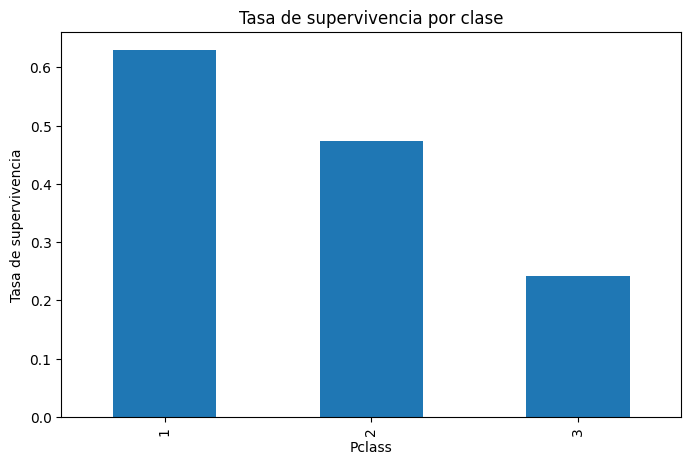

In [27]:
plt.figure(figsize=(8, 5))
df_clean.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Tasa de supervivencia por clase')
plt.ylabel('Tasa de supervivencia')
plt.xlabel('Pclass')
plt.show()

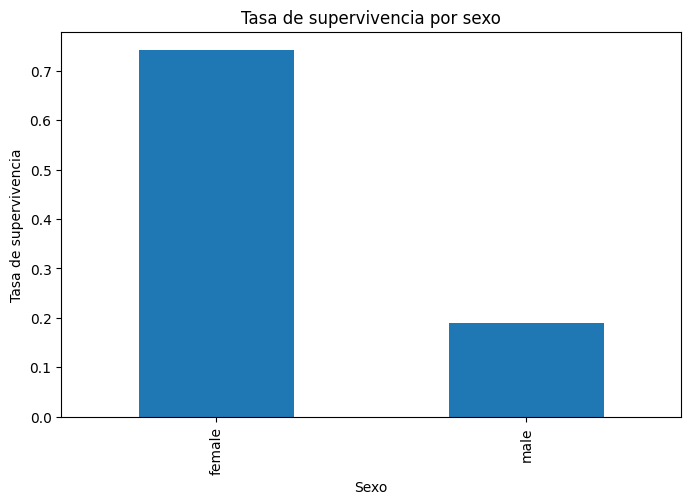

In [28]:
plt.figure(figsize=(8, 5))
df_clean.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Tasa de supervivencia por sexo')
plt.ylabel('Tasa de supervivencia')
plt.xlabel('Sexo')
plt.show()

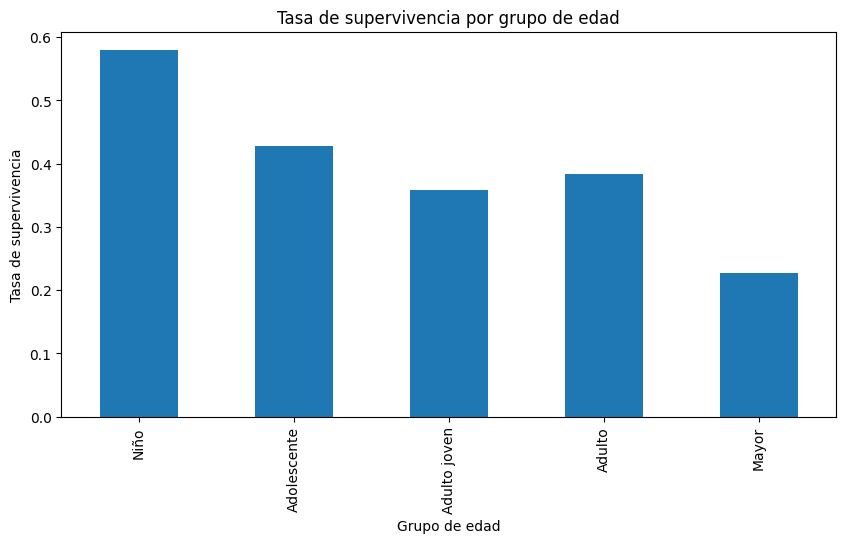

In [29]:
plt.figure(figsize=(10, 5))
df_clean.groupby('AgeBand', observed=False)['Survived'].mean().plot(kind='bar')
plt.title('Tasa de supervivencia por grupo de edad')
plt.ylabel('Tasa de supervivencia')
plt.xlabel('Grupo de edad')
plt.show()

## 12. Tabla final ejecutiva

Creamos una tabla final que un analista sí podría exportar o compartir.

In [30]:
executive_table = (
    df_clean
    .groupby(['Pclass', 'Sex', 'AgeBand'], observed=False)
    .agg(
        pasajeros=('PassengerId', 'count'),
        sobrevivientes=('Survived', 'sum'),
        tasa_supervivencia=('Survived', 'mean'),
        tarifa_promedio=('Fare', 'mean'),
        edad_promedio=('Age', 'mean')
    )
    .reset_index()
)

executive_table['tasa_supervivencia'] = executive_table['tasa_supervivencia'].round(3)
executive_table['tarifa_promedio'] = executive_table['tarifa_promedio'].round(2)
executive_table['edad_promedio'] = executive_table['edad_promedio'].round(1)

display(executive_table.sort_values(['tasa_supervivencia', 'pasajeros'], ascending=[False, False]).head(20))

,Pclass,Sex,AgeBand,pasajeros,sobrevivientes,tasa_supervivencia,tarifa_promedio,edad_promedio
1,1,female,Adolescente,10,10,1.000,125.07,16.5
15,2,male,Niño,9,9,1.000,27.31,2.3
10,2,female,Niño,8,8,1.000,30.35,4.9
11,2,female,Adolescente,6,6,1.000,18.01,16.2
5,1,male,Niño,3,3,1.000,117.80,5.3
4,1,female,Mayor,2,2,1.000,78.98,62.5
24,3,female,Mayor,1,1,1.000,9.59,63.0
2,1,female,Adulto joven,45,44,0.978,107.73,28.9
3,1,female,Adulto,36,35,0.972,99.10,46.2
12,2,female,Adulto joven,42,39,0.929,21.44,27.5


## 13. Conclusiones

Con este ejemplo ya no solo hicimos un análisis básico. También vimos cómo:

- revisar calidad de datos,
- imputar valores faltantes,
- crear variables derivadas,
- usar `groupby`, `transform`, `pivot_table` y `query`,
- construir tablas ejecutivas finales.

Ese flujo se parece mucho más a un caso real de trabajo con pandas.